In [5]:
import pandas as pd

# Load the dataset using the exact path from your screenshot
df = pd.read_csv('/StudentPerformanceFactors.csv')

# Display the first 5 rows of the dataset
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
# 1. Check the total number of rows and columns
print("Dataset Shape:", df.shape)
print("-" * 30)

# 2. Get a summary of all columns, non-null counts, and data types
df.info()

Dataset Shape: (6607, 20)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   obj

In [7]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Print only the columns that have missing values, to keep it clean
print("Missing Values per Column:")
print("-" * 30)
print(missing_values[missing_values > 0])

Missing Values per Column:
------------------------------
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


In [8]:
# Drop all rows that have any missing values
df = df.dropna()

# Verify that the missing values are gone
print("Missing values after cleaning:")
print("-" * 30)
print(df.isnull().sum())
print("\nNew Dataset Shape:", df.shape)

Missing values after cleaning:
------------------------------
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

New Dataset Shape: (6378, 20)


In [9]:
# Count the number of exact duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# If there are duplicates, this will drop them automatically
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates dropped! New Dataset Shape:", df.shape)
else:
    print("No duplicates found. The dataset is ready!")

Number of duplicate rows: 0
No duplicates found. The dataset is ready!


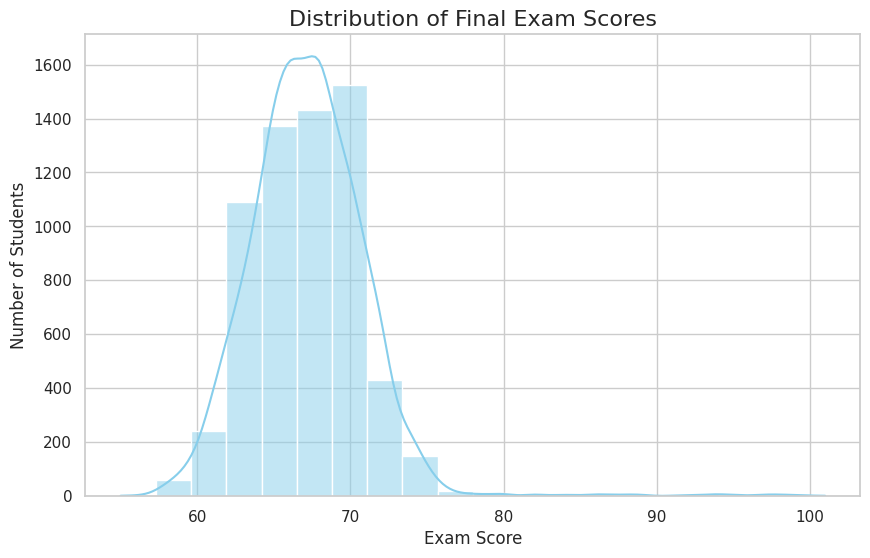


Exam Score Summary Statistics:
count    6378.000000
mean       67.252117
std         3.914217
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for our charts to make them look professional
sns.set_theme(style="whitegrid")

# Create a figure
plt.figure(figsize=(10, 6))

# Plot the distribution of Exam_Score
sns.histplot(df['Exam_Score'], kde=True, bins=20, color='skyblue')

# Add titles and labels
plt.title('Distribution of Final Exam Scores', fontsize=16)
plt.xlabel('Exam Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

# Show the plot
plt.show()

# Print some basic statistics about the target
print("\nExam Score Summary Statistics:")
print(df['Exam_Score'].describe())

In [11]:
# Check how many students have a score above 100
outliers = df[df['Exam_Score'] > 100]
print(f"Number of students with scores above 100: {len(outliers)}")

# Since it's likely an error, we will cap any score above 100 down to 100.
# This keeps the rest of the student's valuable data instead of deleting them.
df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100

# Verify the maximum score is now 100
print("New Maximum Exam Score:", df['Exam_Score'].max())

Number of students with scores above 100: 1
New Maximum Exam Score: 100


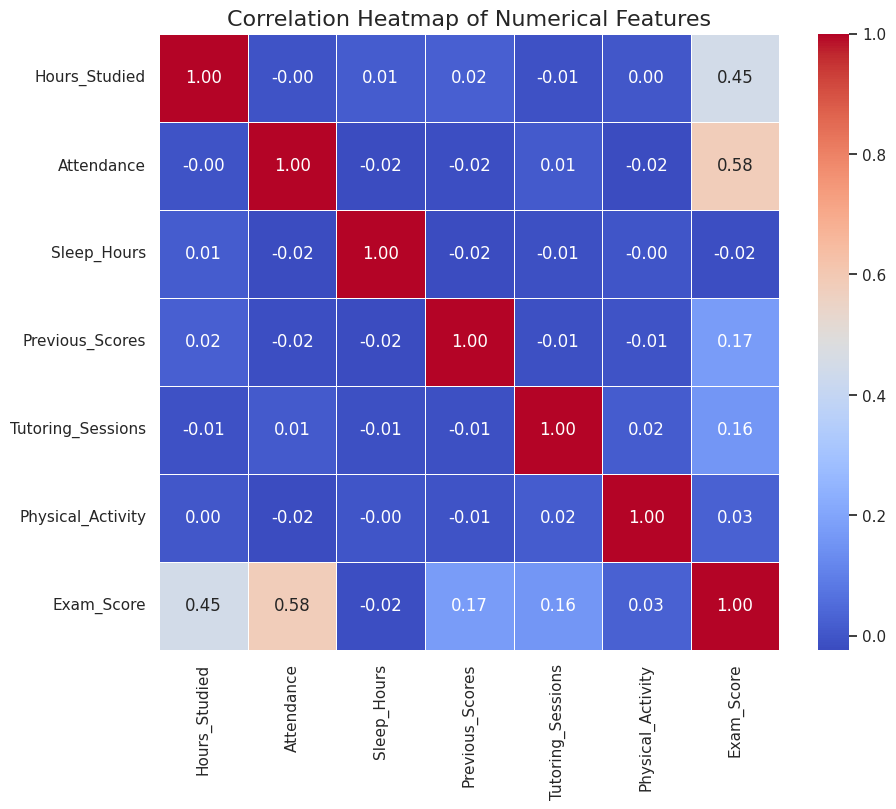


Correlation with Exam_Score:
------------------------------
Exam_Score           1.000000
Attendance           0.580394
Hours_Studied        0.445209
Previous_Scores      0.174292
Tutoring_Sessions    0.156769
Physical_Activity    0.025155
Sleep_Hours         -0.017149
Name: Exam_Score, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the data to only include numerical columns (numbers)
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# 3. Create a colorful heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# 4. Print the exact numbers for the Exam_Score specifically
print("\nCorrelation with Exam_Score:")
print("-" * 30)
print(correlation_matrix['Exam_Score'].sort_values(ascending=False))

/tmp/ipykernel_1517/1870679513.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Parental_Involvement', y='Exam_Score', data=df, order=['Low', 'Medium', 'High'], palette='Set2')


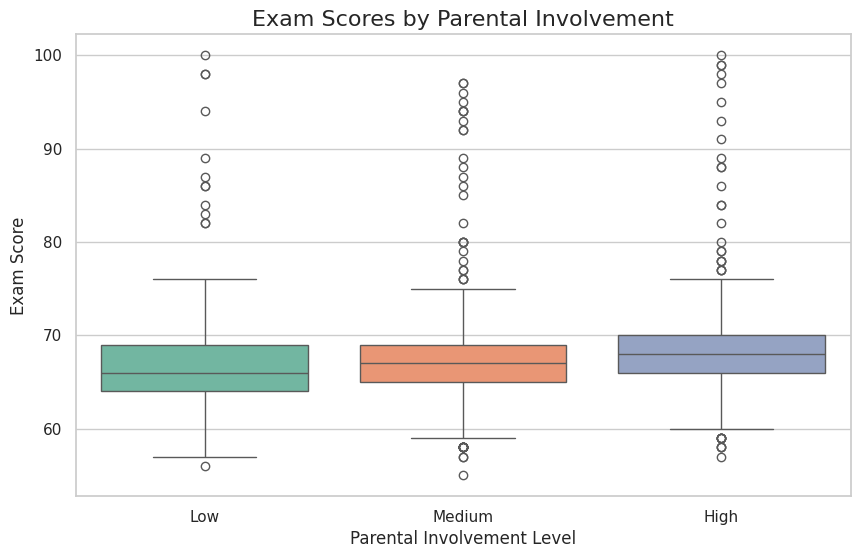


Average Exam Score by Parental Involvement:
---------------------------------------------
Parental_Involvement
High      68.112200
Medium    67.113196
Low       66.378002
Name: Exam_Score, dtype: float64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a boxplot comparing Parental Involvement to Exam Scores
# order=['Low', 'Medium', 'High'] forces the boxes to appear in a logical order
sns.boxplot(x='Parental_Involvement', y='Exam_Score', data=df, order=['Low', 'Medium', 'High'], palette='Set2')

# Add titles and labels
plt.title('Exam Scores by Parental Involvement', fontsize=16)
plt.xlabel('Parental Involvement Level', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)

# Show the plot
plt.show()

# Print the average score for each group to see the exact numbers
print("\nAverage Exam Score by Parental Involvement:")
print("-" * 45)
print(df.groupby('Parental_Involvement')['Exam_Score'].mean().sort_values(ascending=False))

In [14]:
# 1. Define our target variable (y)
y = df['Exam_Score']

# 2. Define our input features (X) by dropping the target column
X = df.drop(columns=['Exam_Score'])

# 3. Verify the shapes
print("Shape of X (Inputs):", X.shape)
print("Shape of y (Output):", y.shape)

# Let's peek at the first few rows of X to confirm Exam_Score is gone
X.head()

Shape of X (Inputs): (6378, 19)
Shape of y (Output): (6378,)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female


In [15]:
# Create a list of columns that contain numerical data
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create a list of columns that contain categorical (text) data
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Print the lists
print("Numerical Features (Need Scaling):")
print("-" * 35)
print(numerical_cols)
print(f"Total: {len(numerical_cols)}")

print("\nCategorical Features (Need Encoding):")
print("-" * 35)
print(categorical_cols)
print(f"Total: {len(categorical_cols)}")

Numerical Features (Need Scaling):
-----------------------------------
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Total: 6

Categorical Features (Need Encoding):
-----------------------------------
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Total: 13


In [16]:
import pandas as pd

# Use pandas get_dummies to perfectly one-hot encode all categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Print the new shape of our input data
print("Original Shape of X:", X.shape)
print("New Shape of X_encoded:", X_encoded.shape)

# Display the first few rows to see the new 0 and 1 columns
X_encoded.head()

Original Shape of X: (6378, 19)
New Shape of X_encoded: (6378, 27)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,True,False,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,True,False,False,True,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,False,True,False,True,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,True,False,False,True,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,False,True,False,True,...,False,True,True,False,False,False,False,False,True,False


In [17]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Print the sizes of our new datasets
print("Training Data Size (X_train):", X_train.shape)
print("Testing Data Size (X_test):", X_test.shape)

Training Data Size (X_train): (5102, 27)
Testing Data Size (X_test): (1276, 27)


In [18]:
from sklearn.preprocessing import StandardScaler

# 1. Create the scaler tool
scaler = StandardScaler()

# 2. Make copies of our datasets so we don't break the originals
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 3. Fit the scaler on the TRAINING data numbers, and transform them
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# 4. ONLY transform the TESTING data numbers (no fitting!)
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Display the first 5 rows to see the new scaled numbers
print("Data successfully scaled!")
X_train_scaled.head()

Data successfully scaled!


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
2356,-0.327672,1.297772,-0.032323,1.451922,0.414729,0.998735,True,False,False,False,...,False,False,False,True,True,True,False,True,False,True
4758,-0.660829,0.778588,0.649136,-1.181929,0.414729,0.032022,False,False,False,True,...,True,True,True,False,False,False,False,True,False,True
2281,-0.660829,-0.952023,-0.713783,-1.389865,-0.397223,-1.901405,False,True,False,False,...,False,True,False,False,False,True,False,True,False,True
485,-1.493721,-1.298145,-0.032323,0.204308,0.414729,0.032022,False,True,False,False,...,True,True,True,False,False,False,True,False,True,False
4200,0.172064,1.297772,0.649136,-1.251241,-0.397223,0.032022,False,True,False,False,...,True,True,False,True,False,True,False,False,True,True


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Create the Linear Regression model
lr_model = LinearRegression()

# 2. Train the model using our study material (the 80% training data)
lr_model.fit(X_train_scaled, y_train)

# 3. Give the model its final exam: Ask it to predict scores for the 20% test data
lr_predictions = lr_model.predict(X_test_scaled)

# 4. Grade the exam using three standard metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

# 5. Print out the final report card
print("Linear Regression Results:")
print("-" * 30)
print(f"MAE:  {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R²:   {lr_r2:.4f}")

Linear Regression Results:
------------------------------
MAE:  0.49
RMSE: 2.04
R²:   0.7314


In [20]:
from sklearn.ensemble import RandomForestRegressor

# 1. Create the Random Forest model
# n_estimators=200 means we are planting 200 "decision trees" to vote on the score
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

# 2. Train the model using the exact same 80% training data
rf_model.fit(X_train_scaled, y_train)

# 3. Give the model the exact same final exam (the 20% test data)
rf_predictions = rf_model.predict(X_test_scaled)

# 4. Grade the exam using the exact same metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

# 5. Print out the final report card
print("Random Forest Results:")
print("-" * 30)
print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²:   {rf_r2:.4f}")

Random Forest Results:
------------------------------
MAE:  1.24
RMSE: 2.44
R²:   0.6175


In [21]:
'''
Model	              MAE	|  RMSE	| R²
Linear Regression |	0.49|	2.04	| 0.7314
Random Forest	    | 1.24| 2.44	| 0.6175
Linear regression wins due to lower MAE,lower RMSE and higher R².
'''

'\nModel\t              MAE\t|  RMSE\t| R²\nLinear Regression |\t0.49|\t2.04\t| 0.7314\nRandom Forest\t    | 1.24| 2.44\t| 0.6175\nLinear regression wins due to lower MAE,lower RMSE and higher R².\n'

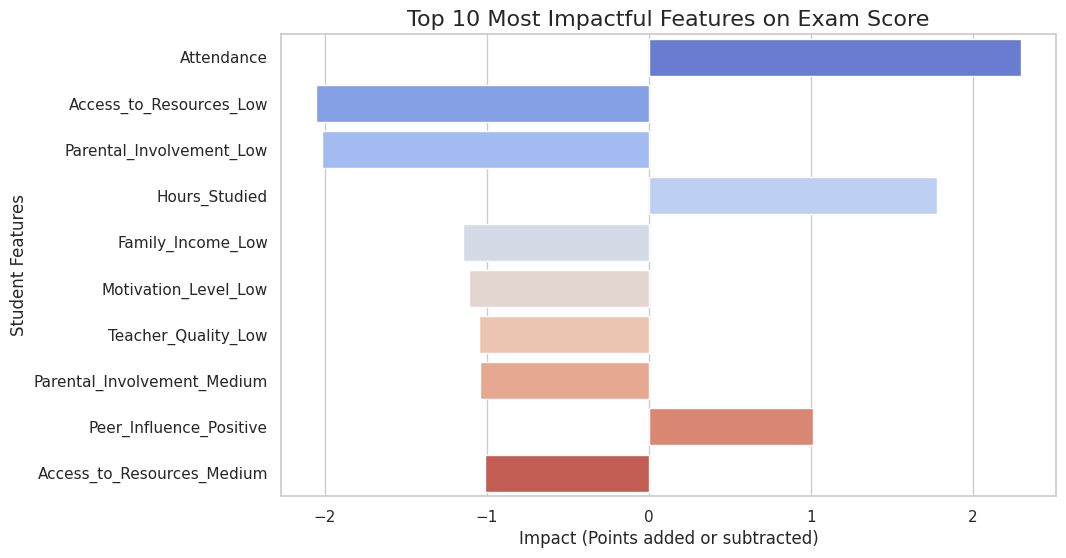

Top 5 Most Important Features:
-----------------------------------
                     Feature  Importance
1                 Attendance    2.295870
8    Access_to_Resources_Low   -2.050406
6   Parental_Involvement_Low   -2.013260
0              Hours_Studied    1.775711
14         Family_Income_Low   -1.147490


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the mathematical weights (coefficients) from our winning model
coefficients = lr_model.coef_

# 2. Pair those weights with our feature names
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': coefficients
})

# 3. Sort them by their absolute value (biggest impact, whether positive or negative)
coef_df['Absolute_Importance'] = coef_df['Importance'].abs()
coef_df = coef_df.sort_values(by='Absolute_Importance', ascending=False)

# 4. Plot the top 10 most impactful features
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Importance', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Top 10 Most Impactful Features on Exam Score', fontsize=16)
plt.xlabel('Impact (Points added or subtracted)', fontsize=12)
plt.ylabel('Student Features', fontsize=12)
plt.show()

# 5. Print the exact numbers for the top 5
print("Top 5 Most Important Features:")
print("-" * 35)
print(coef_df[['Feature', 'Importance']].head())

In [23]:
import joblib

# 1. Save the trained Linear Regression model
joblib.dump(lr_model, 'student_model.pkl')

# 2. Save the fitted StandardScaler so future inputs are scaled identically
joblib.dump(scaler, 'student_scaler.pkl')

print("Model and scaler successfully saved to disk!")

Model and scaler successfully saved to disk!


In [27]:
!pkill streamlit

In [34]:
# Automatically generate the requirements.txt file required for cloud deployment
requirements = """streamlit>=1.20.0
pandas>=1.3.0
scikit-learn>=1.0.0
joblib>=1.1.0
numpy>=1.20.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt has been successfully created!")

requirements.txt has been successfully created!


In [36]:
requirements = """streamlit>=1.20.0
pandas>=1.3.0
scikit-learn>=1.0.0
joblib>=1.1.0
numpy>=1.20.0
plotly>=5.0.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt updated with plotly!")

requirements.txt updated with plotly!


In [37]:
 #Run this code in a new cell to download requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>